In [49]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv(r"C:\Users\IT\Desktop\Data Analysis\AnalystLab Africa Internship\OnlineRetail.csv\OnlineRetail_Dataset.csv",encoding='latin1')
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [4]:
#- Identify columns with missing values.
df.isnull().sum() 

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [5]:
# Creating table for missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing

CustomerID     135080
Description      1454
StockCode           0
InvoiceNo           0
Quantity            0
InvoiceDate         0
UnitPrice           0
Country             0
dtype: int64

In [8]:
#Filling Missing Values
df['CustomerID'] = df['CustomerID'].fillna(df['CustomerID'].mode()[0])
df['CustomerID'] 

0         17850.0
1         17850.0
2         17850.0
3         17850.0
4         17850.0
           ...   
541904    12680.0
541905    12680.0
541906    12680.0
541907    12680.0
541908    12680.0
Name: CustomerID, Length: 541909, dtype: float64

In [10]:
##Filling Missing Values
df['Description']=df['Description'].fillna("Unknown")
df['Description']

0          WHITE HANGING HEART T-LIGHT HOLDER
1                         WHITE METAL LANTERN
2              CREAM CUPID HEARTS COAT HANGER
3         KNITTED UNION FLAG HOT WATER BOTTLE
4              RED WOOLLY HOTTIE WHITE HEART.
                         ...                 
541904            PACK OF 20 SPACEBOY NAPKINS
541905           CHILDREN'S APRON DOLLY GIRL 
541906          CHILDRENS CUTLERY DOLLY GIRL 
541907        CHILDRENS CUTLERY CIRCUS PARADE
541908          BAKING SET 9 PIECE RETROSPOT 
Name: Description, Length: 541909, dtype: str

In [12]:
#Check If Any value is missing
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [23]:
  # Identify duplicate rows.
df.duplicated().sum()

np.int64(0)

In [21]:
#Remove Duplicates
print("Duplicates Before:", df.duplicated().sum())
before=len(df)
df=df.drop_duplicates()
after=len(df)
print("Duplicate Removed- ",before - after)

Duplicates Before: 0
Duplicate Removed-  0


In [34]:
#- Date formats
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])
df['InvoiceDate'].head()

0   2010-12-01 08:26:00
1   2010-12-01 08:26:00
2   2010-12-01 08:26:00
3   2010-12-01 08:26:00
4   2010-12-01 08:26:00
Name: InvoiceDate, dtype: datetime64[us]

In [30]:
df.columns
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [38]:
# Column Names
df.columns=df.columns.str.strip().str.lower() # column name converted into lower case
df.columns

Index(['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate',
       'unitprice', 'customerid', 'country'],
      dtype='str')

In [40]:
# Text Format
df['country']=df['country'].str.title()
df['country']

0         United Kingdom
1         United Kingdom
2         United Kingdom
3         United Kingdom
4         United Kingdom
               ...      
541904            France
541905            France
541906            France
541907            France
541908            France
Name: country, Length: 536641, dtype: str

In [41]:
df['description']=df['description'].str.title()
df['description']

0          White Hanging Heart T-Light Holder
1                         White Metal Lantern
2              Cream Cupid Hearts Coat Hanger
3         Knitted Union Flag Hot Water Bottle
4              Red Woolly Hottie White Heart.
                         ...                 
541904            Pack Of 20 Spaceboy Napkins
541905           Children'S Apron Dolly Girl 
541906          Childrens Cutlery Dolly Girl 
541907        Childrens Cutlery Circus Parade
541908          Baking Set 9 Piece Retrospot 
Name: description, Length: 536641, dtype: str

In [43]:
#- Invalid values
df[df['quantity']<=0]


In [45]:
# Remove Invalid Quantity
df=df[df['quantity']>0]
df

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country
0,536365,85123A,White Hanging Heart T-Light Holder,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,White Metal Lantern,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,Cream Cupid Hearts Coat Hanger,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,Knitted Union Flag Hot Water Bottle,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,Red Woolly Hottie White Heart.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,Pack Of 20 Spaceboy Napkins,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,Children'S Apron Dolly Girl,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,Childrens Cutlery Dolly Girl,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,Childrens Cutlery Circus Parade,4,2011-12-09 12:50:00,4.15,12680.0,France


In [46]:
# Invalid Price
df[df['unitprice']<=0]

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country
622,536414,22139,Unknown,56,2010-12-01 11:52:00,0.0,17841.0,United Kingdom
1970,536545,21134,Unknown,1,2010-12-01 14:32:00,0.0,17841.0,United Kingdom
1971,536546,22145,Unknown,1,2010-12-01 14:33:00,0.0,17841.0,United Kingdom
1972,536547,37509,Unknown,1,2010-12-01 14:33:00,0.0,17841.0,United Kingdom
1987,536549,85226A,Unknown,1,2010-12-01 14:34:00,0.0,17841.0,United Kingdom
...,...,...,...,...,...,...,...,...
535334,581211,22142,Check,14,2011-12-07 18:36:00,0.0,17841.0,United Kingdom
536981,581234,72817,Unknown,27,2011-12-08 10:33:00,0.0,17841.0,United Kingdom
538504,581406,46000M,Polyester Filler Pad 45X45Cm,240,2011-12-08 13:58:00,0.0,17841.0,United Kingdom
538505,581406,46000S,Polyester Filler Pad 40X40Cm,300,2011-12-08 13:58:00,0.0,17841.0,United Kingdom


In [47]:
#Remove INvalid Price
df=df[df['unitprice']>0]
df

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country
0,536365,85123A,White Hanging Heart T-Light Holder,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,White Metal Lantern,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,Cream Cupid Hearts Coat Hanger,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,Knitted Union Flag Hot Water Bottle,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,Red Woolly Hottie White Heart.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,Pack Of 20 Spaceboy Napkins,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,Children'S Apron Dolly Girl,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,Childrens Cutlery Dolly Girl,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,Childrens Cutlery Circus Parade,4,2011-12-09 12:50:00,4.15,12680.0,France


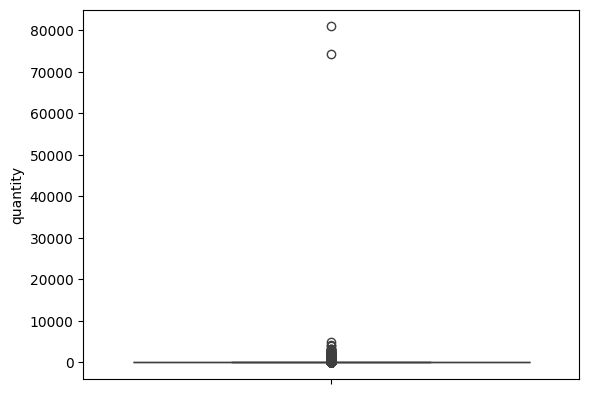

In [51]:
#- Outliers or anomalies where applicable
sns.boxplot(df['quantity'])
plt.show()

In [52]:
df.describe()

,quantity,invoicedate,unitprice,customerid
count,524878.000000,524878,524878.000000,524878.000000
mean,10.616600,2011-07-04 15:30:16.317049,3.922573,15930.834230
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000
25%,1.000000,2011-03-28 12:13:00,1.250000,14375.000000
50%,4.000000,2011-07-20 11:22:00,2.080000,16265.000000
75%,11.000000,2011-10-19 11:41:00,4.130000,17841.000000
max,80995.000000,2011-12-09 12:50:00,13541.330000,18287.000000
std,156.280031,NaN,36.093028,1850.669004


In [ ]:
Create a summary table showing:

Issue Found	                               |Action Taken

Missing CustomerID	                       |Filled with mode
Missing Description	                       |Filled with Unknown
Duplicates	                               |Removed
Invalid Quantity	                       |Removed
Invalid Unitprice                          |Removed
Date Format                                |Converted to datetime
Country Format	                           |Converted to uppercase
Column Names                               |Standardized


In [53]:
# Save clean file
df.to_csv("cleaned_online_retail.csv", index=False)   